In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import os

if os.getcwd().split("/")[-1] == "notebooks":
    os.chdir("../")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from notebooks.imports import *
from config import dir_config, main_config

## Configuration

Design matrix adds `prior_strength` (directional prior) and keeps `color` (prior condition cue).

**5-group structure** (matching `3.40-ddm-fit-subtypes.ipynb`):
- HC
- Tremor OFF / Tremor ON
- Brady OFF / Brady ON

In [3]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = Path(processed_dir, 'glm_hmm_models')
glm_hmm_dir.mkdir(exist_ok=True)

MODEL_NAME = 'prior_model_NoColor_1back'

# Feature configuration — INPUT_DIM = 5
CURRENT_TRIAL_FEATURES = ['normalized_stimulus', 'bias']
PREV_TRIAL_FEATURES    = ['prev_choice', 'prev_coherence', 'prev_choice_coherence']
N_TRIALS_BACK          = 1

MODEL_FEATURES = CURRENT_TRIAL_FEATURES + [
    f'{var}_{n+1}' for n in range(N_TRIALS_BACK) for var in PREV_TRIAL_FEATURES
]
INPUT_DIM = len(MODEL_FEATURES)

print('Model features:', MODEL_FEATURES)
print('Input dimension:', INPUT_DIM)

Model features: ['normalized_stimulus', 'bias', 'prev_choice_1', 'prev_coherence_1', 'prev_choice_coherence_1']
Input dimension: 5


## Load Data

We need two files:
- `processed_all_data_accu_60_filtered.csv` — behavioral data for all subjects (HC + PD)
- `processed_metadata_all_data_accu_60.csv` — metadata with `is_pd`, `treatment`, `trem_vs_brady_type`, `session_id`

In [4]:
data = pd.read_csv(Path(processed_dir, 'processed_all_data_accu_60_filtered.csv'))
metadata = pd.read_csv(Path(processed_dir, 'processed_metadata_all_data_accu_60.csv'))

data.choice  = data.choice.fillna(-1).astype(int)
data.target  = data.target.fillna(-1).astype(int)
data.outcome = data.outcome.fillna(-1).astype(int)

print('Behavioral data shape:', data.shape)
print('Metadata shape:', metadata.shape)
print('Metadata columns:', metadata.columns.tolist())

Behavioral data shape: (63097, 16)
Metadata shape: (100, 80)
Metadata columns: ['subject_id', 'gender', 'age', 'years_since_diagnosis', 'pd_meds', 'is_pd', 'treatment', 'off_med_first', 'MoCA', 'off_meds_hrs', '210_Tremor', '212_Balance', '213_Freezing', '301_Speech', '302_Facial_Expression', '303a_Rigidity_Neck', '303b_Rigidity_RUE', '303c_Rigidity_LUE', '303d_Rigidity_RLE', '303e_Rigidity_LLE', '304a_Finger_Tapping_RUE', '304b_Finger_Tapping_LUE', '305a_Hand_Movements_RUE', '305b_Hand_Movements_LUE', '306a_Pronation_Supination_Movements_RUE', '306b_Pronation_Supination_Movements_LUE', '307a_Toe_Tapping_RLE', '307b_Toe_Tapping_LLE', '308a_Leg_Agility_RLE', '308b_Leg_Agility_LLE', '309_Arising_from_Chair', '310_Gait', '311_Freezing_of_Gait', '312_Postural_Stability', '313_Posture', '314_Global_Spontaneity_of_Movement', '315a_Postural_Tremor_RUE', '315b_Postural_Tremor_LUE', '316a_Kinetic_Tremor_RUE', '316b_Kinetic_Tremor_LUE', '317a_Rest_Tremor_Amplitude_RUE', '317b_Rest_Tremor_Amplitu

## Build 5-Group Session ID Lists

Group membership is determined from the metadata using `is_pd`, `trem_vs_brady_type`, and `treatment`.
- **HC**: `is_pd == 0`
- **Tremor OFF/ON**: `trem_vs_brady_type == 'tremor'` × `treatment`
- **Brady OFF/ON**: `trem_vs_brady_type == 'bradykinetic'` × `treatment`
- **Intermediate** (P24): excluded from subtype groups

In [5]:
# Verify required columns exist
required_cols = ['is_pd', 'trem_vs_brady_type', 'treatment', 'session_id', 'subject_id']
missing = [c for c in required_cols if c not in metadata.columns]
if missing:
    print(f'WARNING: missing metadata columns: {missing}')
    print('Available:', metadata.columns.tolist())
else:
    print('All required metadata columns present.')

All required metadata columns present.


In [6]:
# --- HC sessions (is_pd == 0, single session per subject) ---
hc_meta = metadata[metadata['is_pd'] == 0]
hc_session_ids = sorted(hc_meta['session_id'].dropna().unique().tolist())
hc_subjects    = sorted(hc_meta['subject_id'].unique().tolist())
print(f'HC subjects (n={len(hc_subjects)}): {hc_subjects}')
print(f'HC sessions (n={len(hc_session_ids)}): {hc_session_ids}')

HC subjects (n=18): ['AV', 'BC', 'BF', 'EM', 'ES', 'GF', 'GP', 'HC1', 'HC12', 'HC13', 'HC3', 'HC6', 'HC7', 'HC8', 'HC9', 'JA', 'MRM', 'SY']
HC sessions (n=18): ['AV', 'BC', 'BF', 'EM', 'ES', 'GF', 'GP', 'HC1', 'HC12', 'HC13', 'HC3', 'HC6', 'HC7', 'HC8', 'HC9', 'JA', 'MRM', 'SY']


In [7]:
# --- PD subtype × medication groups ---
pd_meta = metadata[metadata['is_pd'] == 1]

tremor_subjects  = sorted(pd_meta[pd_meta['trem_vs_brady_type'] == 'tremor']['subject_id'].unique().tolist())
brady_subjects   = sorted(pd_meta[pd_meta['trem_vs_brady_type'] == 'bradykinetic']['subject_id'].unique().tolist())
intermed_subjects = sorted(pd_meta[pd_meta['trem_vs_brady_type'] == 'intermediate']['subject_id'].unique().tolist())

print(f'Tremor-dominant (n={len(tremor_subjects)}): {tremor_subjects}')
print(f'Bradykinetic    (n={len(brady_subjects)}):  {brady_subjects}')
print(f'Intermediate    (n={len(intermed_subjects)}): {intermed_subjects}  ← excluded from subtype groups')

Tremor-dominant (n=11): ['P11', 'P12', 'P17', 'P18', 'P19', 'P29', 'P3', 'P31', 'P32', 'P6', 'P7']
Bradykinetic    (n=10):  ['P1', 'P13', 'P20', 'P22', 'P23', 'P28', 'P33', 'P34', 'P4', 'P9']
Intermediate    (n=1): ['P24']  ← excluded from subtype groups


In [8]:
def get_session_ids(meta, subjects, treatment_label):
    """Return sorted session IDs for subjects in a given treatment state."""
    return sorted(
        meta[
            (meta['subject_id'].isin(subjects)) &
            (meta['treatment'].str.upper() == treatment_label.upper())
        ]['session_id'].dropna().unique().tolist()
    )

tremor_off_ids = get_session_ids(pd_meta, tremor_subjects, 'OFF')
tremor_on_ids  = get_session_ids(pd_meta, tremor_subjects, 'ON')
brady_off_ids  = get_session_ids(pd_meta, brady_subjects,  'OFF')
brady_on_ids   = get_session_ids(pd_meta, brady_subjects,  'ON')

print(f'Tremor OFF sessions (n={len(tremor_off_ids)}): {tremor_off_ids}')
print(f'Tremor ON  sessions (n={len(tremor_on_ids)}):  {tremor_on_ids}')
print(f'Brady OFF  sessions (n={len(brady_off_ids)}):  {brady_off_ids}')
print(f'Brady ON   sessions (n={len(brady_on_ids)}):   {brady_on_ids}')

Tremor OFF sessions (n=11): ['P11_OFF', 'P12_OFF', 'P17_OFF', 'P18_OFF', 'P19_OFF', 'P29_OFF', 'P31_OFF', 'P32_OFF', 'P3_OFF', 'P6_OFF', 'P7_OFF']
Tremor ON  sessions (n=11):  ['P11_ON', 'P12_ON', 'P17_ON', 'P18_ON', 'P19_ON', 'P29_ON', 'P31_ON', 'P32_ON', 'P3_ON', 'P6_ON', 'P7_ON']
Brady OFF  sessions (n=10):  ['P13_OFF', 'P1_OFF', 'P20_OFF', 'P22_OFF', 'P23_OFF', 'P28_OFF', 'P33_OFF', 'P34_OFF', 'P4_OFF', 'P9_OFF']
Brady ON   sessions (n=10):   ['P13_ON', 'P1_ON', 'P20_ON', 'P22_ON', 'P23_ON', 'P28_ON', 'P33_ON', 'P34_ON', 'P4_ON', 'P9_ON']


## Build Subject-Level ON/OFF Pairing

For paired statistics (Wilcoxon signed-rank), we need to match each subject's OFF session to their ON session.

In [9]:
def build_subject_pairs(meta, subjects):
    """Return dict mapping subject_id -> {'off': session_id, 'on': session_id}."""
    pairs = {}
    for subj in subjects:
        subj_meta = meta[meta['subject_id'] == subj]
        off_rows = subj_meta[subj_meta['treatment'].str.upper() == 'OFF']['session_id'].dropna()
        on_rows  = subj_meta[subj_meta['treatment'].str.upper() == 'ON']['session_id'].dropna()
        if len(off_rows) == 1 and len(on_rows) == 1:
            pairs[subj] = {'off': off_rows.values[0], 'on': on_rows.values[0]}
        else:
            print(f'  WARNING: {subj} has {len(off_rows)} OFF and {len(on_rows)} ON sessions — skipping.')
    return pairs

tremor_pairs = build_subject_pairs(pd_meta, tremor_subjects)
brady_pairs  = build_subject_pairs(pd_meta, brady_subjects)

print(f'Tremor subject pairs (n={len(tremor_pairs)}):')
for s, p in tremor_pairs.items():
    print(f'  {s}: OFF={p["off"]}, ON={p["on"]}')
print(f'\nBrady subject pairs (n={len(brady_pairs)}):')
for s, p in brady_pairs.items():
    print(f'  {s}: OFF={p["off"]}, ON={p["on"]}')

Tremor subject pairs (n=11):
  P11: OFF=P11_OFF, ON=P11_ON
  P12: OFF=P12_OFF, ON=P12_ON
  P17: OFF=P17_OFF, ON=P17_ON
  P18: OFF=P18_OFF, ON=P18_ON
  P19: OFF=P19_OFF, ON=P19_ON
  P29: OFF=P29_OFF, ON=P29_ON
  P3: OFF=P3_OFF, ON=P3_ON
  P31: OFF=P31_OFF, ON=P31_ON
  P32: OFF=P32_OFF, ON=P32_ON
  P6: OFF=P6_OFF, ON=P6_ON
  P7: OFF=P7_OFF, ON=P7_ON

Brady subject pairs (n=10):
  P1: OFF=P1_OFF, ON=P1_ON
  P13: OFF=P13_OFF, ON=P13_ON
  P20: OFF=P20_OFF, ON=P20_ON
  P22: OFF=P22_OFF, ON=P22_ON
  P23: OFF=P23_OFF, ON=P23_ON
  P28: OFF=P28_OFF, ON=P28_ON
  P33: OFF=P33_OFF, ON=P33_ON
  P34: OFF=P34_OFF, ON=P34_ON
  P4: OFF=P4_OFF, ON=P4_ON
  P9: OFF=P9_OFF, ON=P9_ON


Verify `color` Encoding (Direction Normalisation)\n\nThe data is pre-normalised so `choice=1` and `signed_coherence>0` always mean *toward the most frequent direction*. Therefore:\n\n- `color = 1` → unequal prior trial; the prior points in the **positive coherence direction** (by construction)\n- `color = 0` → equal prior trial; no directional bias expected\n\nThe GLM weight on `color` directly measures prior integration: high weight = biases choice toward the most frequent direction on unequal prior trials. No sign-flip or separate `prior_strength` variable is needed.

In [10]:
def verify_color_encoding(df):
    """
    Sanity-check that color encodes the prior condition correctly:
    - On color=1 (unequal prior) trials, p(choice=1) should exceed 0.5 for valid trials
      (subjects should bias toward the prior direction = positive choice = 1)
    - On color=0 (equal prior) trials, p(choice=1) should be near 0.5
    """
    df = df.copy()
    df['color'] = df['color'].fillna(0)
    valid = df[df['outcome'] >= 0]

    for grp_label, grp_data in [('All subjects', valid)]:
        c1 = grp_data[grp_data['color'] == 1]['choice']
        c0 = grp_data[grp_data['color'] == 0]['choice']
        print(f'{grp_label}:')
        print(f'  color=1 (unequal prior): p(choice=1) = {c1.mean():.3f}  (n={len(c1)} trials)')
        print(f'  color=0 (equal prior):   p(choice=1) = {c0.mean():.3f}  (n={len(c0)} trials)')
        if c1.mean() > 0.5:
            print('  ✓ color=1 biases toward most frequent direction (choice=1) as expected')
        else:
            print('  ✗ WARNING: color=1 trials do NOT show positive bias — check encoding')

verify_color_encoding(data)

print('\ncoherence sign verification:')
valid = data[data['outcome'] >= 0]
pos_coh = valid[valid['signed_coherence'] > 0]['choice'].mean()
neg_coh = valid[valid['signed_coherence'] < 0]['choice'].mean()
print(f'  positive coherence → p(choice=1) = {pos_coh:.3f}  (should be > 0.5)')
print(f'  negative coherence → p(choice=1) = {neg_coh:.3f}  (should be < 0.5)')

All subjects:
  color=1 (unequal prior): p(choice=1) = 0.633  (n=31529 trials)
  color=0 (equal prior):   p(choice=1) = 0.495  (n=31568 trials)
  ✓ color=1 biases toward most frequent direction (choice=1) as expected

coherence sign verification:
  positive coherence → p(choice=1) = 0.780  (should be > 0.5)
  negative coherence → p(choice=1) = 0.252  (should be < 0.5)


In [11]:
# Ensure color NaNs are filled (missing coherence/color = invalid trial, masked during fit anyway)
data = data.copy()
data['color'] = data['color'].fillna(0)

print('color value distribution:')
print(data['color'].value_counts().sort_index())
print('\nExpected: 0 (equal prior), 1 (unequal prior — toward most frequent direction)')

color value distribution:
color
0    31568
1    31529
Name: count, dtype: int64

Expected: 0 (equal prior), 1 (unequal prior — toward most frequent direction)


## Verify Data Coverage for Each Group

In [12]:
def session_stats(df, session_ids, label):
    rows = []
    for sid in session_ids:
        sess = df[df['session_id'] == sid]
        valid = (sess['outcome'] >= 0).sum()
        total = len(sess)
        prior_dir = sess['prior_direction'].iloc[0] if len(sess) > 0 else 'N/A'
        n_unequal = (sess['color'] == 1).sum()
        n_equal   = (sess['color'] == 0).sum()
        rows.append({'session_id': sid, 'total': total, 'valid': valid,
                     'prior_dir': prior_dir, 'n_unequal': n_unequal, 'n_equal': n_equal})
    df_stats = pd.DataFrame(rows)
    if len(df_stats) > 0:
        print(f'\n{label} (n={len(df_stats)} sessions, '
              f'mean valid={df_stats["valid"].mean():.0f}±{df_stats["valid"].std():.0f}):')
        print(df_stats.to_string(index=False))
    else:
        print(f'{label}: no sessions found in behavioral data')
    return df_stats

all_session_ids = {
    'HC':         hc_session_ids,
    'Tremor OFF': tremor_off_ids,
    'Tremor ON':  tremor_on_ids,
    'Brady OFF':  brady_off_ids,
    'Brady ON':   brady_on_ids,
}

stats_tables = {}
for label, ids in all_session_ids.items():
    stats_tables[label] = session_stats(data, ids, label)


HC (n=18 sessions, mean valid=626±25):
session_id  total  valid prior_dir  n_unequal  n_equal
        AV    679    679     right        339      340
        BC    633    633     right        319      314
        BF    617    617     right        312      305
        EM    655    655      left        329      326
        ES    665    665      left        332      333
        GF    620    620     right        316      304
        GP    600    600      left        300      300
       HC1    591    591     right        296      295
      HC12    584    584     right        284      300
      HC13    631    631      left        315      316
       HC3    621    621     right        315      306
       HC6    602    602      left        305      297
       HC7    602    602     right        302      300
       HC8    636    636      left        317      319
       HC9    640    640     right        320      320
        JA    623    623      left        313      310
       MRM    626    626 

## Feature Distribution Plots

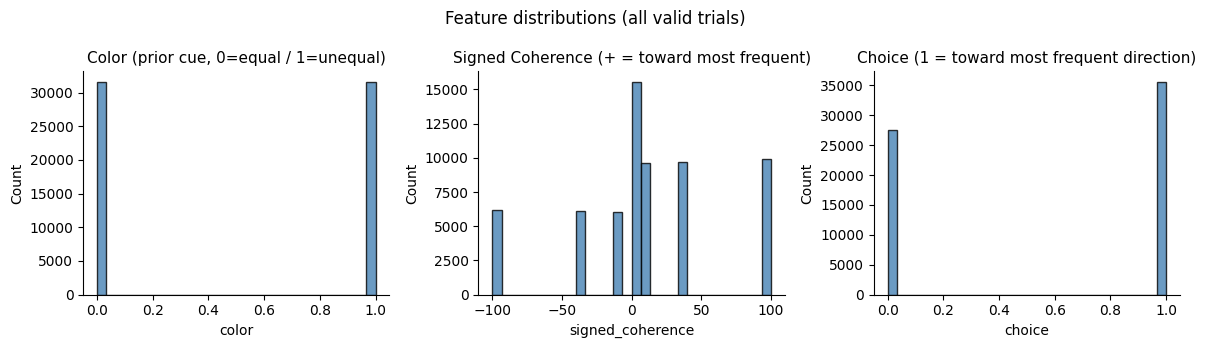

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (feat, lbl) in zip(axes, [
    ('color',            'Color (prior cue, 0=equal / 1=unequal)'),
    ('signed_coherence', 'Signed Coherence (+ = toward most frequent)'),
    ('choice',           'Choice (1 = toward most frequent direction)'),
]):
    valid = data[data['outcome'] >= 0]
    ax.hist(valid[feat].dropna(), bins=30, edgecolor='k', color='steelblue', alpha=0.8)
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
plt.suptitle('Feature distributions (all valid trials)', fontsize=12)
plt.tight_layout()
plt.show()

## Save Configuration and Data

In [14]:
feature_config = {
    'model_name':             MODEL_NAME,
    'current_trial_features': CURRENT_TRIAL_FEATURES,
    'prev_trial_features':    PREV_TRIAL_FEATURES,
    'n_trials_back':          N_TRIALS_BACK,
    'model_features':         MODEL_FEATURES,
    'input_dim':              INPUT_DIM,
    # 5-group session IDs
    'session_ids': {
        'hc':         hc_session_ids,
        'tremor_off': tremor_off_ids,
        'tremor_on':  tremor_on_ids,
        'brady_off':  brady_off_ids,
        'brady_on':   brady_on_ids,
    },
    # Subject-level ON/OFF pairing for paired statistics
    'subject_pairs': {
        'tremor': tremor_pairs,
        'brady':  brady_pairs,
    },
    'subject_ids': {
        'hc':           hc_subjects,
        'tremor':       tremor_subjects,
        'brady':        brady_subjects,
        'intermediate': intermed_subjects,
    },
}

# Save behavioral data (color NaNs already filled)
data.to_csv(Path(glm_hmm_dir, f'{MODEL_NAME}_data.csv'), index=False)

with open(Path(glm_hmm_dir, f'{MODEL_NAME}_config.pkl'), 'wb') as f:
    pickle.dump(feature_config, f)

print('Saved:')
print(f'  {glm_hmm_dir}/{MODEL_NAME}_data.csv')
print(f'  {glm_hmm_dir}/{MODEL_NAME}_config.pkl')
print('\nFeature summary:')
print(f'  MODEL_NAME:     {MODEL_NAME}')
print(f'  MODEL_FEATURES: {MODEL_FEATURES}')
print(f'  INPUT_DIM:      {INPUT_DIM}')
print('\nGroup session counts:')
for grp, ids in feature_config['session_ids'].items():
    print(f'  {grp:<12}: {len(ids)} sessions')

Saved:
  /mnt/pd-data/processed/glm_hmm_models/prior_model_NoColor_1back_data.csv
  /mnt/pd-data/processed/glm_hmm_models/prior_model_NoColor_1back_config.pkl

Feature summary:
  MODEL_NAME:     prior_model_NoColor_1back
  MODEL_FEATURES: ['normalized_stimulus', 'bias', 'prev_choice_1', 'prev_coherence_1', 'prev_choice_coherence_1']
  INPUT_DIM:      5

Group session counts:
  hc          : 18 sessions
  tremor_off  : 11 sessions
  tremor_on   : 11 sessions
  brady_off   : 10 sessions
  brady_on    : 10 sessions
